# Lab 5 – SAM-based Water Quality Classification with S2 Calibration

**Goal:** Fuse airborne hyperspectral data with Sentinel-2 to build a water quality monitoring tool.

## Approach

```
Airborne HS (1 m, 456 bands)
   │
   ├─► Simulate S2 reflectance via spectral response functions (SRF)
   │       └─► ELC calibration: regress real S2 against synthetic S2
   │                └─► Calibrated S2 bands (radiometrically consistent with HS)
   │
   ├─► Extract water quality reference spectra (Clear / Turbid / Algal)
   │       └─► Simulate through S2 SRFs → S2 reference spectra
   │
   └─► SAM: spectral angle of each S2 pixel vs. each reference spectrum
           └─► Random Forest: SAM angles + calibrated bands + indices → WQ class map
```

**Reference:** lab_3 (deforestation.ipynb) — SAM was used there for Soil/Water/Vegetation discrimination on Landsat data using the same arccos-based angle metric.

## 0. Setup

In [31]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import zoom as nd_zoom, uniform_filter

import spectral.io.envi as envi
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.crs import CRS
from pyproj import Transformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pystac_client
import planetary_computer

plt.rcParams['figure.dpi'] = 110

DATA_DIR       = Path('data/Obrazy lotnicze')
OUT_DIR        = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

SCALE_FACTOR   = 10_000.0
IGNORE_VALUE   = 15_000.0
EPSG_LOCAL     = 2177

# ── acquisition date (same as in water_quality_analysis.ipynb) ───────────────
ACQUISITION_DATE   = '2025-06-17'   # ← update to actual flight date
SEARCH_WINDOW_DAYS = 30

print('Setup complete.')

Setup complete.


## 1. Load Hyperspectral Data

In [32]:
HDR_FILES = {
    'block_008': DATA_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.hdr',
    'block_013': DATA_DIR / '221000_Odra_HS_Blok_A_013_VS_join_atm.hdr',
    'block_015': DATA_DIR / '221000_Odra_HS_Blok_A_015_VS_join_atm.hdr',
}


def load_envi(hdr_path):
    img  = envi.open(str(hdr_path))
    meta = img.metadata
    return img, meta


def get_wavelengths(meta):
    return np.array([float(w) for w in meta['wavelength']])


def get_map_origin(meta):
    map_info = meta['map info']
    parts = [p.strip() for p in (map_info if isinstance(map_info, list)
                                  else str(map_info).strip('{}').split(','))]
    return float(parts[3]), float(parts[4])   # (easting, northing)


def find_band(target_nm, wavelengths):
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def read_band(img, band_idx):
    data = img.read_bands([band_idx]).squeeze().astype(np.float32)
    data = np.where((data >= IGNORE_VALUE) | (data < 0), np.nan, data)
    return data / SCALE_FACTOR


blocks = {}
for name, hdr in HDR_FILES.items():
    img, meta = load_envi(hdr)
    wl         = get_wavelengths(meta)
    origin     = get_map_origin(meta)
    blocks[name] = dict(img=img, meta=meta, wl=wl, origin=origin)
    print(f'{name}: {img.nrows}×{img.ncols}×{img.nbands}  '
          f'λ {wl[0]:.0f}–{wl[-1]:.0f} nm  origin E={origin[0]:.0f} N={origin[1]:.0f}')

block_008: 4300×2001×456  λ 414–2499 nm  origin E=6509736 N=5580712
block_013: 1800×4324×456  λ 414–2499 nm  origin E=6510302 N=5581560
block_015: 2838×3862×456  λ 414–2499 nm  origin E=6517216 N=5581457


## 2. Sentinel-2 Spectral Response Functions (SRF)

Each Sentinel-2 band is modelled as a **Gaussian filter** centred at the band's nominal wavelength  
with the instrument's full-width at half-maximum (FWHM).  
This is a standard approximation used when official tabulated SRFs are unavailable.

The synthetic reflectance for band $b$ at pixel $p$ is:
$$R_b^{\text{sim}}(p) = \frac{\int R^{\text{HS}}(p,\lambda)\,\text{SRF}_b(\lambda)\,d\lambda}{\int \text{SRF}_b(\lambda)\,d\lambda}$$

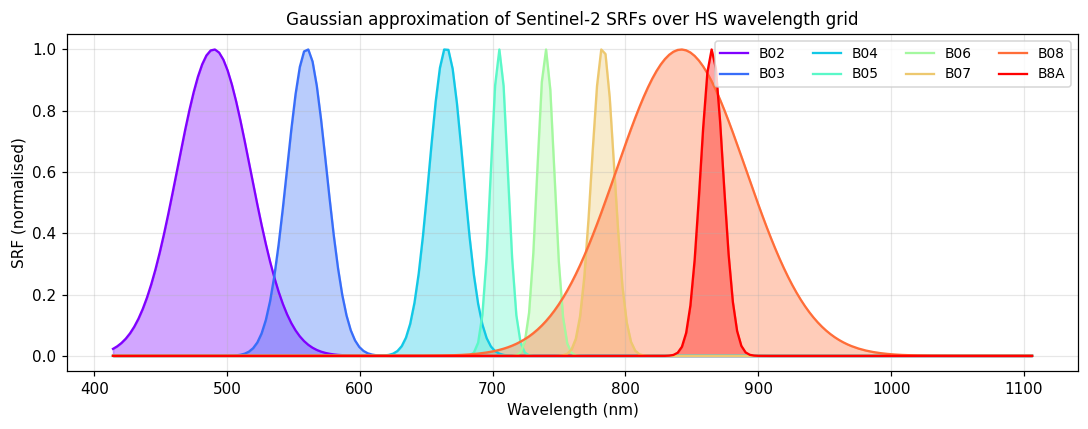

In [33]:
# Band centre (nm) and FWHM (nm) — Sentinel-2 MSI instrument specs
S2_BAND_DEFS = {
    'B02': (490,  65),
    'B03': (560,  35),
    'B04': (665,  30),
    'B05': (705,  15),
    'B06': (740,  15),
    'B07': (783,  20),
    'B08': (842, 115),
    'B8A': (865,  20),
}


def gaussian_srf(wavelengths, centre, fwhm):
    """Unit-normalised Gaussian spectral response function."""
    sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    g = np.exp(-0.5 * ((wavelengths - centre) / sigma) ** 2)
    return g / g.max()


# Pre-compute SRF arrays over the HS wavelength grid
wl = blocks['block_008']['wl']
srfs = {name: gaussian_srf(wl, centre, fwhm)
        for name, (centre, fwhm) in S2_BAND_DEFS.items()}

# ── plot SRFs ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.rainbow(np.linspace(0, 1, len(srfs)))
for (band, srf), c in zip(srfs.items(), colors):
    ax.fill_between(wl[:200], srf[:200], alpha=0.35, color=c)
    ax.plot(wl[:200], srf[:200], color=c, linewidth=1.5, label=band)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('SRF (normalised)')
ax.set_title('Gaussian approximation of Sentinel-2 SRFs over HS wavelength grid')
ax.legend(ncol=4, fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'srf_plot.png', bbox_inches='tight', dpi=130)
plt.show()

## 3. Simulate S2 Reflectance from Hyperspectral Data

We read the HS cube **one band at a time** (memory-efficient) and accumulate  
the weighted sum for each S2 band.

In [34]:
def simulate_s2_from_hs(img, wl, srfs, srf_threshold=0.01):
    """
    Simulate all S2 bands from a hyperspectral image.
    Reads the HS cube band-by-band for memory efficiency.

    Returns dict {band_name: 2-D reflectance array}.
    """
    nrows, ncols = img.nrows, img.ncols
    result = {}

    for band_name, srf in srfs.items():
        # Only process HS bands where SRF > threshold (skip negligible tails)
        active = np.where(srf > srf_threshold)[0]
        if len(active) == 0:
            result[band_name] = np.full((nrows, ncols), np.nan, dtype=np.float32)
            continue

        numerator   = np.zeros((nrows, ncols), dtype=np.float64)
        denominator = 0.0

        for b_idx in active:
            w = srf[b_idx]
            hs_band = read_band(img, b_idx)   # (nrows, ncols) float32
            valid = np.isfinite(hs_band)
            numerator[valid] += hs_band[valid] * w
            denominator      += w

        result[band_name] = (numerator / denominator).astype(np.float32)
        print(f'  {band_name}: integrated over {len(active)} HS bands  '
              f'(mean refl = {np.nanmean(result[band_name]):.4f})')

    return result


print('Simulating S2 from block_008 hyperspectral data…')
hs_sim_s2 = simulate_s2_from_hs(blocks['block_008']['img'], wl, srfs)
print('Done.')

Simulating S2 from block_008 hyperspectral data…
  B02: integrated over 50 HS bands  (mean refl = 0.0000)
  B03: integrated over 28 HS bands  (mean refl = 0.0000)
  B04: integrated over 24 HS bands  (mean refl = 0.0000)
  B05: integrated over 13 HS bands  (mean refl = 0.0000)
  B06: integrated over 12 HS bands  (mean refl = 0.0000)
  B07: integrated over 16 HS bands  (mean refl = 0.0000)
  B08: integrated over 90 HS bands  (mean refl = 0.0000)
  B8A: integrated over 17 HS bands  (mean refl = 0.0000)
Done.


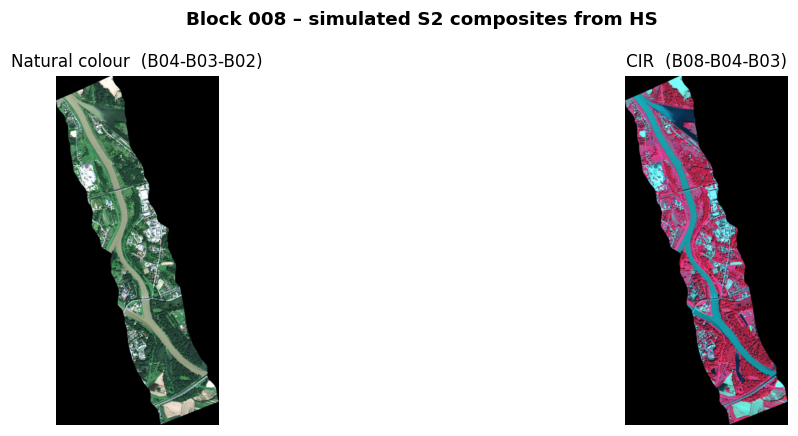

In [35]:
# Quick visual check: simulated S2 natural colour composite from HS
def stretch(arr, pct=(2, 98)):
    lo, hi = np.nanpercentile(arr, pct)
    return np.clip((arr - lo) / max(hi - lo, 1e-9), 0, 1)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Block 008 – simulated S2 composites from HS', fontweight='bold')

# Natural colour (B04/B03/B02)
nc = np.dstack([stretch(hs_sim_s2[b]) for b in ['B04', 'B03', 'B02']])
axes[0].imshow(np.nan_to_num(nc), interpolation='bilinear')
axes[0].set_title('Natural colour  (B04-B03-B02)')
axes[0].axis('off')

# CIR
cir = np.dstack([stretch(hs_sim_s2[b]) for b in ['B08', 'B04', 'B03']])
axes[1].imshow(np.nan_to_num(cir), interpolation='bilinear')
axes[1].set_title('CIR  (B08-B04-B03)')
axes[1].axis('off')

fig.tight_layout()
fig.savefig(OUT_DIR / 'hs_simulated_s2_composites.png', bbox_inches='tight', dpi=130)
plt.show()

## 4. Cross-Calibration of Sentinel-2 Using Airborne Data

### Concept: Empirical Line Calibration (ELC)

The airborne hyperspectral data serves as a high-quality radiometric reference.  
By comparing **synthetic S2 reflectance** (simulated from HS via SRF convolution)  
with **actual S2 reflectance** at co-located water pixels, we estimate  
a per-band linear correction:

$$R_b^{\text{actual}} = g_b \cdot R_b^{\text{synthetic}} + o_b$$

Inverting gives the calibrated S2 reflectance:

$$R_b^{\text{cal}} = \frac{R_b^{\text{actual}} - o_b}{g_b}$$

**Why water pixels?**  Water has stable, featureless reflectance in the NIR–SWIR range  
and the river pixels are well-distributed across the scene, giving good dynamic range  
for regression.

In [36]:
from datetime import datetime, timedelta

# ── water mask for block_008 ──────────────────────────────────────────────────
nir_b   = read_band(blocks['block_008']['img'], find_band(780, wl))
green_b = read_band(blocks['block_008']['img'], find_band(560, wl))
ndwi_hs = (green_b - nir_b) / (green_b + nir_b + 1e-9)
water_mask_hs = (nir_b < 0.05) & (ndwi_hs > 0.0) & np.isfinite(nir_b)
print(f'HS water mask: {water_mask_hs.sum():,} pixels')

# ── project HS extent to WGS84 for S2 search ─────────────────────────────────
transformer = Transformer.from_crs(f'EPSG:{EPSG_LOCAL}', 'EPSG:4326', always_xy=True)
img_008     = blocks['block_008']['img']
e0, n0      = blocks['block_008']['origin']
e1  = e0 + img_008.ncols
n1  = n0 - img_008.nrows
lons, lats = transformer.transform([e0, e1], [n0, n1])
bbox_wgs84 = [min(lons)-0.01, min(lats)-0.01, max(lons)+0.01, max(lats)+0.01]

acq_date   = datetime.strptime(ACQUISITION_DATE, '%Y-%m-%d')
date_start = (acq_date - timedelta(days=SEARCH_WINDOW_DAYS)).strftime('%Y-%m-%d')
date_end   = (acq_date + timedelta(days=SEARCH_WINDOW_DAYS)).strftime('%Y-%m-%d')
print(f'Search bbox: {[round(x,4) for x in bbox_wgs84]}')
print(f'Date range:  {date_start} → {date_end}')

HS water mask: 467,497 pixels
Search bbox: [18.1268, 50.3135, 18.1748, 50.3722]
Date range:  2025-05-18 → 2025-07-17


In [37]:
# ── download S2 L2A ───────────────────────────────────────────────────────────
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)
search = catalog.search(
    collections=['sentinel-2-l2a'],
    bbox=bbox_wgs84,
    datetime=f'{date_start}/{date_end}',
    query={'eo:cloud_cover': {'lt': 30}},
)
items = list(search.items())

def temporal_dist(it):
    return abs((datetime.fromisoformat(it.datetime.strftime('%Y-%m-%d')) - acq_date).days)

best_item = min(items, key=temporal_dist)
best_date = best_item.datetime.strftime('%Y-%m-%d')
delta_days = temporal_dist(best_item)
print(f'Selected: {best_item.id}  ({best_date}, Δ={delta_days} days, '
      f'cloud={best_item.properties["eo:cloud_cover"]:.1f}%)')


def read_s2_band_windowed(item, band_name, bbox):
    href = item.assets[band_name].href
    with rasterio.open(href) as src:
        from rasterio.windows import from_bounds as wb
        t = Transformer.from_crs('EPSG:4326', src.crs.to_epsg(), always_xy=True)
        x0, y0 = t.transform(bbox[0], bbox[1])
        x1, y1 = t.transform(bbox[2], bbox[3])
        window = wb(min(x0,x1), min(y0,y1), max(x0,x1), max(y0,y1), src.transform)
        data      = src.read(1, window=window).astype(np.float32)
        transform = src.window_transform(window)
        profile   = {'crs': src.crs, 'transform': transform,
                     'width': data.shape[1], 'height': data.shape[0]}
    return data, profile


S2_CALIB_BANDS = list(S2_BAND_DEFS.keys()) + ['SCL']
s2_raw, s2_profiles = {}, {}
for band in S2_CALIB_BANDS:
    print(f'  Downloading {band}…', end=' ', flush=True)
    data, prof      = read_s2_band_windowed(best_item, band, bbox_wgs84)
    s2_raw[band]    = data
    s2_profiles[band] = prof
    print(f'{data.shape[0]}×{data.shape[1]}')

# Convert to reflectance
s2_refl = {b: np.where(s2_raw[b]==0, np.nan, s2_raw[b].astype(np.float32)) / 10000.0
           for b in S2_BAND_DEFS}
scl = s2_raw['SCL'].astype(np.uint8)
print('Download complete.')

Selected: S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401  (2025-06-15, Δ=2 days, cloud=0.5%)
Download complete.


In [38]:
# ── reproject HS-simulated S2 onto actual S2 10 m grid ────────────────────────
# We use block_008 → reproject each synthetic band from CS2000 Z6 to S2's UTM CRS.

def reproject_to_s2(src_data, hs_origin, s2_profile):
    nrows, ncols = src_data.shape
    left, top    = hs_origin
    right        = left + ncols
    bottom       = top  - nrows
    src_crs      = CRS.from_epsg(EPSG_LOCAL)
    dst_crs      = s2_profile['crs']

    dst_transform, dst_w, dst_h = calculate_default_transform(
        src_crs, dst_crs, ncols, nrows,
        left=left, bottom=bottom, right=right, top=top,
    )
    dst = np.full((dst_h, dst_w), np.nan, dtype=np.float32)
    src_transform = rasterio.transform.from_bounds(left, bottom, right, top, ncols, nrows)
    reproject(
        source=src_data.astype(np.float32),
        destination=dst,
        src_transform=src_transform, src_crs=src_crs,
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.average,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst, dst_transform


origin_008 = blocks['block_008']['origin']
ref_profile = s2_profiles['B04']   # 10 m reference grid

hs_sim_s2_reproj = {}
for band_name, sim_data in hs_sim_s2.items():
    reproj, _ = reproject_to_s2(sim_data, origin_008, ref_profile)
    # Snap to exact S2 shape
    tgt = s2_refl['B04'].shape
    if reproj.shape != tgt:
        reproj = nd_zoom(reproj, (tgt[0]/reproj.shape[0], tgt[1]/reproj.shape[1]), order=1)
    hs_sim_s2_reproj[band_name] = reproj
    print(f'  {band_name}: reprojected → {reproj.shape}')

print('Reprojection complete.')

  B02: reprojected → (667, 314)
  B03: reprojected → (667, 314)
  B04: reprojected → (667, 314)
  B05: reprojected → (667, 314)
  B06: reprojected → (667, 314)
  B07: reprojected → (667, 314)
  B08: reprojected → (667, 314)
  B8A: reprojected → (667, 314)
Reprojection complete.


In [39]:
# ── build S2 water mask (SCL class 6 + NDWI) ─────────────────────────────────
shape_10m = s2_refl['B04'].shape
scl_up    = nd_zoom(scl.astype(np.float32),
                    (shape_10m[0]/scl.shape[0], shape_10m[1]/scl.shape[1]), order=0).astype(np.uint8)

ndwi_s2   = ((s2_refl['B03'] - s2_refl['B08']) /
             (s2_refl['B03'] + s2_refl['B08'] + 1e-9))
s2_water  = (np.isin(scl_up, [6]) | (ndwi_s2 > 0.0)) & np.isfinite(s2_refl['B04'])

# ── also reproject HS water mask for overlap detection ────────────────────────
hs_wm_reproj, _ = reproject_to_s2(water_mask_hs.astype(np.float32), origin_008, ref_profile)
if hs_wm_reproj.shape != shape_10m:
    hs_wm_reproj = nd_zoom(hs_wm_reproj, (shape_10m[0]/hs_wm_reproj.shape[0],
                                           shape_10m[1]/hs_wm_reproj.shape[1]), order=0)
hs_water_s2grid = hs_wm_reproj > 0.5   # binary

# Combined mask: pixels classified as water by BOTH sensors → most reliable
calib_mask = s2_water & hs_water_s2grid

# Check HS coverage on S2 grid (HS only covers block_008, not all of S2 scene)
hs_coverage = np.isfinite(hs_sim_s2_reproj['B04'])
calib_mask  = calib_mask & hs_coverage

print(f'Calibration pixels (water, both sensors overlap): {calib_mask.sum():,}')

Calibration pixels (water, both sensors overlap): 816


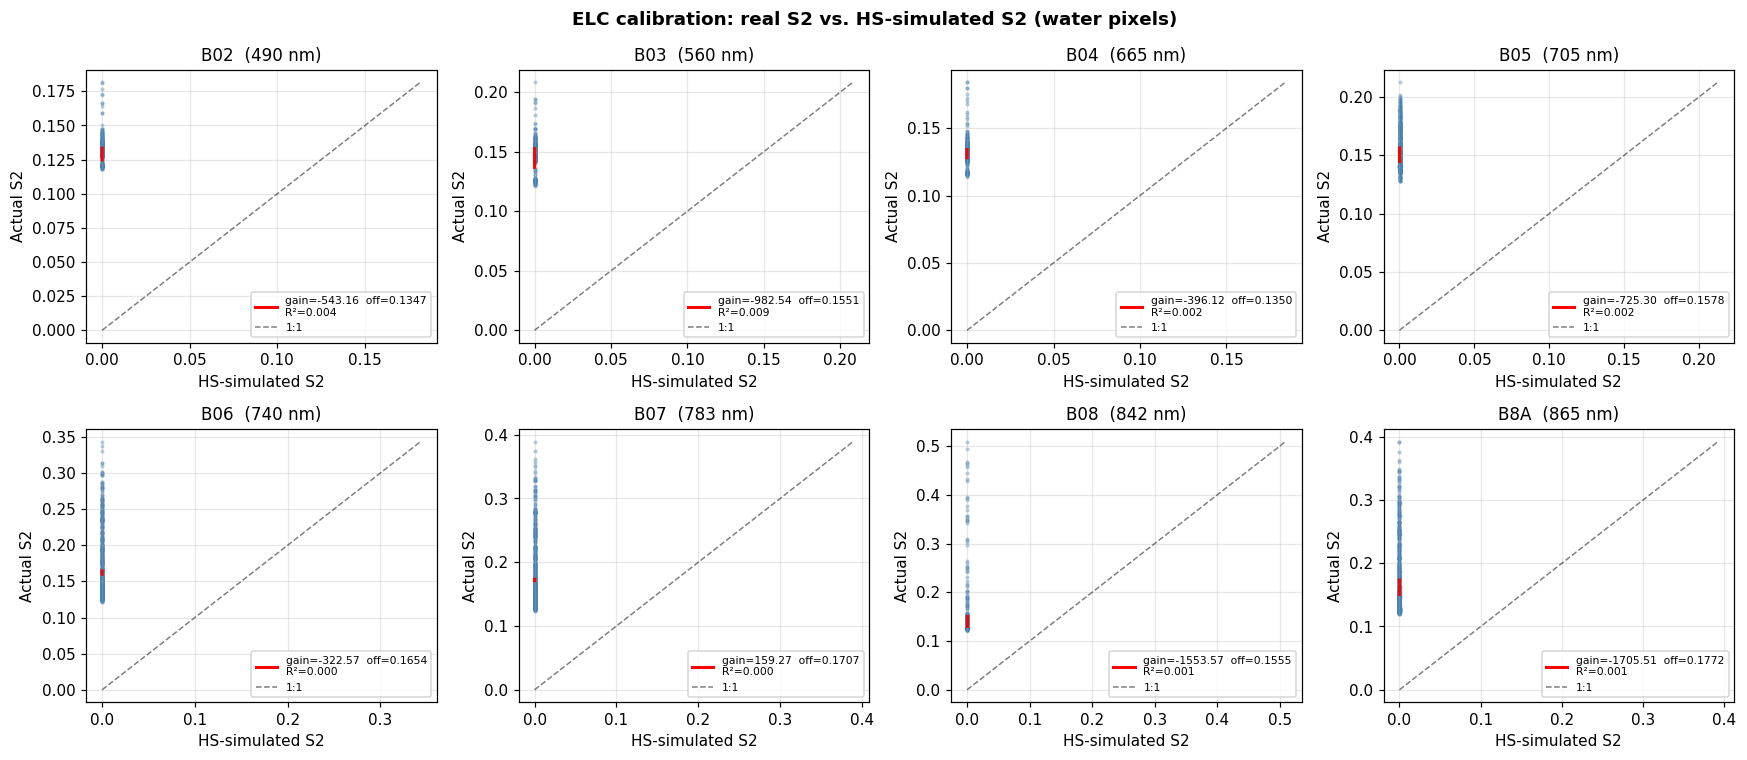


Calibration parameters (gain, offset per band):
  B02: gain=-543.1565  offset=0.13475
  B03: gain=-982.5414  offset=0.15514
  B04: gain=-396.1197  offset=0.13501
  B05: gain=-725.3012  offset=0.15782
  B06: gain=-322.5690  offset=0.16535
  B07: gain=159.2726  offset=0.17066
  B08: gain=-1553.5730  offset=0.15554
  B8A: gain=-1705.5137  offset=0.17720


In [41]:
from sklearn.linear_model import LinearRegression

# Helper: return any S2 band resampled to the 10 m reference grid
def s2_at_10m(band_name):
    data = s2_refl[band_name]
    if data.shape != shape_10m:
        data = nd_zoom(data, (shape_10m[0] / data.shape[0],
                              shape_10m[1] / data.shape[1]), order=1)
    return data

shape_10m = s2_refl['B04'].shape

# ── per-band ELC regression: real S2 = gain * synthetic + offset ──────────────
calib_params = {}  # {band_name: (gain, offset)}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('ELC calibration: real S2 vs. HS-simulated S2 (water pixels)',
             fontsize=12, fontweight='bold')

for ax, band_name in zip(axes.flat, S2_BAND_DEFS):
    x_sim = hs_sim_s2_reproj[band_name][calib_mask]   # synthetic (HS)
    y_act = s2_at_10m(band_name)[calib_mask]           # actual S2 (always 10 m)

    ok = np.isfinite(x_sim) & np.isfinite(y_act)
    x, y = x_sim[ok], y_act[ok]

    if len(x) < 10:
        calib_params[band_name] = (1.0, 0.0)
        ax.set_title(f'{band_name}: insufficient overlap')
        continue

    idx = np.random.choice(len(x), min(len(x), 5_000), replace=False)
    x_s, y_s = x[idx], y[idx]

    reg    = LinearRegression().fit(x_s.reshape(-1, 1), y_s)
    gain   = float(reg.coef_[0])
    offset = float(reg.intercept_)
    r2     = reg.score(x_s.reshape(-1, 1), y_s)
    calib_params[band_name] = (gain, offset)

    ax.scatter(x_s, y_s, s=3, alpha=0.3, color='steelblue')
    xr = np.linspace(x_s.min(), x_s.max(), 100)
    ax.plot(xr, gain * xr + offset, 'r-', linewidth=2,
            label=f'gain={gain:.2f}  off={offset:.4f}\nR²={r2:.3f}')
    lim = (min(x_s.min(), y_s.min()), max(x_s.max(), y_s.max()))
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.5, label='1:1')
    ax.set_title(f'{band_name}  ({S2_BAND_DEFS[band_name][0]} nm)')
    ax.set_xlabel('HS-simulated S2')
    ax.set_ylabel('Actual S2')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / 'elc_calibration_scatter.png', bbox_inches='tight', dpi=130)
plt.show()

print('\nCalibration parameters (gain, offset per band):')
for band, (g, o) in calib_params.items():
    print(f'  {band}: gain={g:.4f}  offset={o:.5f}')


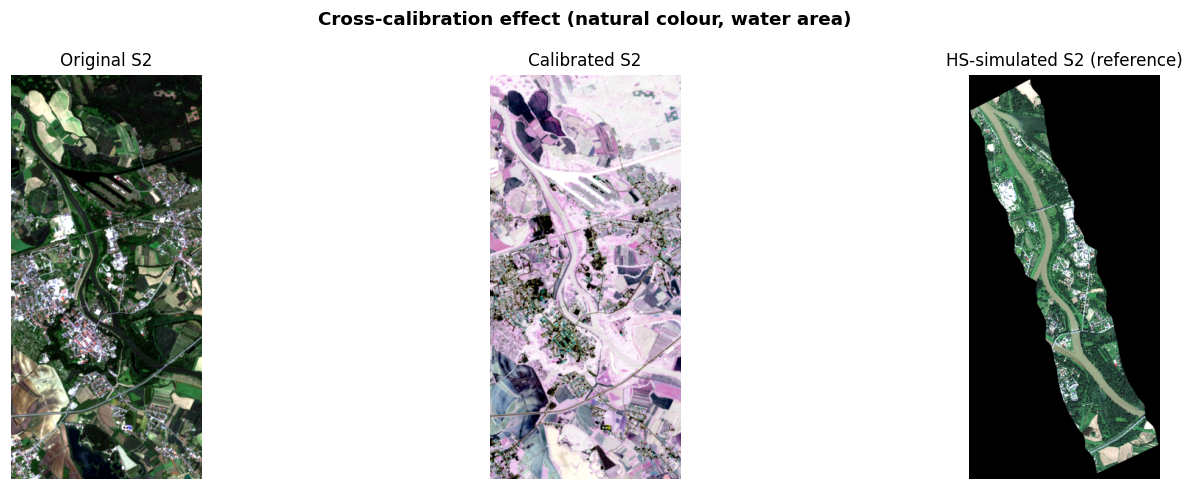

In [42]:
# ── apply calibration: R_cal = (R_actual - offset) / gain ─────────────────────
s2_cal = {}
for band_name in S2_BAND_DEFS:
    gain, offset = calib_params[band_name]
    raw = s2_at_10m(band_name)
    # Guard against division by near-zero gain
    if abs(gain) < 0.05:
        print(f'  {band_name}: gain too small ({gain:.4f}), keeping original')
        s2_cal[band_name] = raw
    else:
        s2_cal[band_name] = np.where(np.isfinite(raw), (raw - offset) / gain, np.nan)

# ── visual comparison: before vs after calibration ────────────────────────────
def make_nc(bands_dict, r='B04', g='B03', b='B02'):
    def s(arr): lo, hi = np.nanpercentile(arr, [2,98]); return np.clip((arr-lo)/max(hi-lo,1e-9),0,1)
    return np.nan_to_num(np.dstack([s(bands_dict[r]), s(bands_dict[g]), s(bands_dict[b])]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Cross-calibration effect (natural colour, water area)',
             fontweight='bold')
axes[0].imshow(make_nc(s2_refl),         interpolation='bilinear')
axes[0].set_title('Original S2')
axes[1].imshow(make_nc(s2_cal),          interpolation='bilinear')
axes[1].set_title('Calibrated S2')
axes[2].imshow(make_nc(hs_sim_s2_reproj), interpolation='bilinear')
axes[2].set_title('HS-simulated S2 (reference)')
for ax in axes: ax.axis('off')
fig.tight_layout()
fig.savefig(OUT_DIR / 'calibration_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

## 5. Water Quality Reference Spectra

We define three water quality classes directly from the HS data using index thresholds,  
then extract the **median HS spectrum** for each class and simulate it through the S2 SRFs.

| Class | NDCI | NDTI | Description |
|-------|------|------|-------------|
| Clear | < 0  | < 0  | Low chl-a, low turbidity |
| Turbid | any | > 0.05 | High suspended sediment |
| Algal | > 0.10 | any | Elevated chlorophyll-a |

  Class 0 (Clear): 146,014 pixels
  Class 1 (Turbid): 320,013 pixels
  Class 2 (Algal): 1,470 pixels


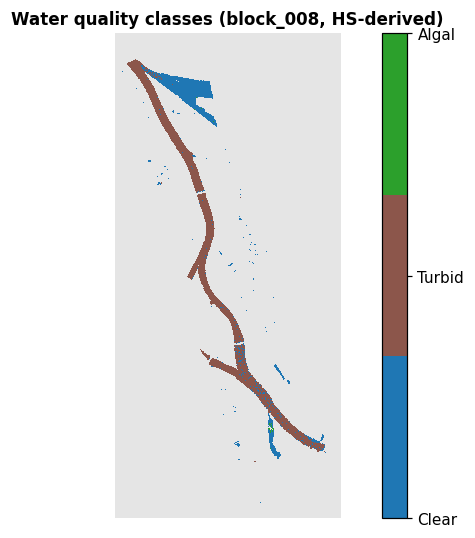

In [43]:
# ── compute NDCI and NDTI for block_008 ──────────────────────────────────────
R665 = read_band(blocks['block_008']['img'], find_band(665, wl))
R709 = read_band(blocks['block_008']['img'], find_band(709, wl))
R560 = read_band(blocks['block_008']['img'], find_band(560, wl))

ndci = (R709 - R665) / (R709 + R665 + 1e-9)
ndti = (R665 - R560) / (R665 + R560 + 1e-9)

# ── assign class labels to water pixels ──────────────────────────────────────
# Priority: Algal > Turbid > Clear  (a pixel can qualify for multiple)
wq_class = np.full(ndci.shape, -1, dtype=np.int8)   # -1 = non-water
wq_class[water_mask_hs]                                         = 0  # Clear (default)
wq_class[water_mask_hs & (ndti > 0.05)]                         = 1  # Turbid
wq_class[water_mask_hs & (ndci > 0.10)]                         = 2  # Algal

CLASS_NAMES   = {0: 'Clear', 1: 'Turbid', 2: 'Algal'}
CLASS_COLORS  = {0: '#1f77b4', 1: '#8c564b', 2: '#2ca02c'}

for cid, cname in CLASS_NAMES.items():
    n = (wq_class == cid).sum()
    print(f'  Class {cid} ({cname}): {n:,} pixels')

# ── visualise class map ───────────────────────────────────────────────────────
cmap_wq = mcolors.ListedColormap(['lightgrey', CLASS_COLORS[0],
                                   CLASS_COLORS[1], CLASS_COLORS[2]])
display_map = np.where(water_mask_hs, wq_class.astype(float), -1)

fig, ax = plt.subplots(figsize=(8, 5))
bg = np.ones((*water_mask_hs.shape, 3)) * 0.9
ax.imshow(bg)
im = ax.imshow(np.where(display_map >= 0, display_map, np.nan),
               cmap=mcolors.ListedColormap([CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]]),
               vmin=0, vmax=2, interpolation='nearest')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels([CLASS_NAMES[k] for k in range(3)])
ax.set_title('Water quality classes (block_008, HS-derived)', fontweight='bold')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUT_DIR / 'wq_class_map_hs.png', bbox_inches='tight', dpi=130)
plt.show()

In [44]:
# ── extract median reference spectra per class ────────────────────────────────
# We read a random subsample of HS bands to keep memory reasonable.
# For the reference spectrum we need the full spectral profile → read all bands.
# Memory estimate: 456 bands × 2001×4300 px × 4 bytes ≈ 15 GB — too large.
# Strategy: read band-by-band, accumulate per-class median using reservoir-style statistics.

MAX_PIXELS_PER_CLASS = 500   # cap for median estimation

# Pre-select representative pixel indices for each class
class_pixel_indices = {}
for cid in CLASS_NAMES:
    rows_c, cols_c = np.where(wq_class == cid)
    n = min(len(rows_c), MAX_PIXELS_PER_CLASS)
    idx = np.random.choice(len(rows_c), n, replace=False)
    class_pixel_indices[cid] = (rows_c[idx], cols_c[idx])
    print(f'  Class {cid} ({CLASS_NAMES[cid]}): {n} reference pixels selected')

# Storage: spectra[cid] → array (n_pixels, n_bands)
n_bands   = blocks['block_008']['img'].nbands
spectra_by_class = {cid: np.full((len(class_pixel_indices[cid][0]), n_bands),
                                   np.nan, dtype=np.float32)
                    for cid in CLASS_NAMES}

img_008 = blocks['block_008']['img']
for b_idx in range(n_bands):
    band_data = img_008.read_bands([b_idx]).squeeze().astype(np.float32)
    band_data  = np.where((band_data >= IGNORE_VALUE) | (band_data < 0),
                           np.nan, band_data) / SCALE_FACTOR
    for cid, (rows_c, cols_c) in class_pixel_indices.items():
        spectra_by_class[cid][:, b_idx] = band_data[rows_c, cols_c]

ref_spectra_hs = {
    cid: np.nanmedian(spectra_by_class[cid], axis=0)
    for cid in CLASS_NAMES
}
print('Reference spectra extracted.')

  Class 0 (Clear): 500 reference pixels selected
  Class 1 (Turbid): 500 reference pixels selected
  Class 2 (Algal): 500 reference pixels selected
Reference spectra extracted.


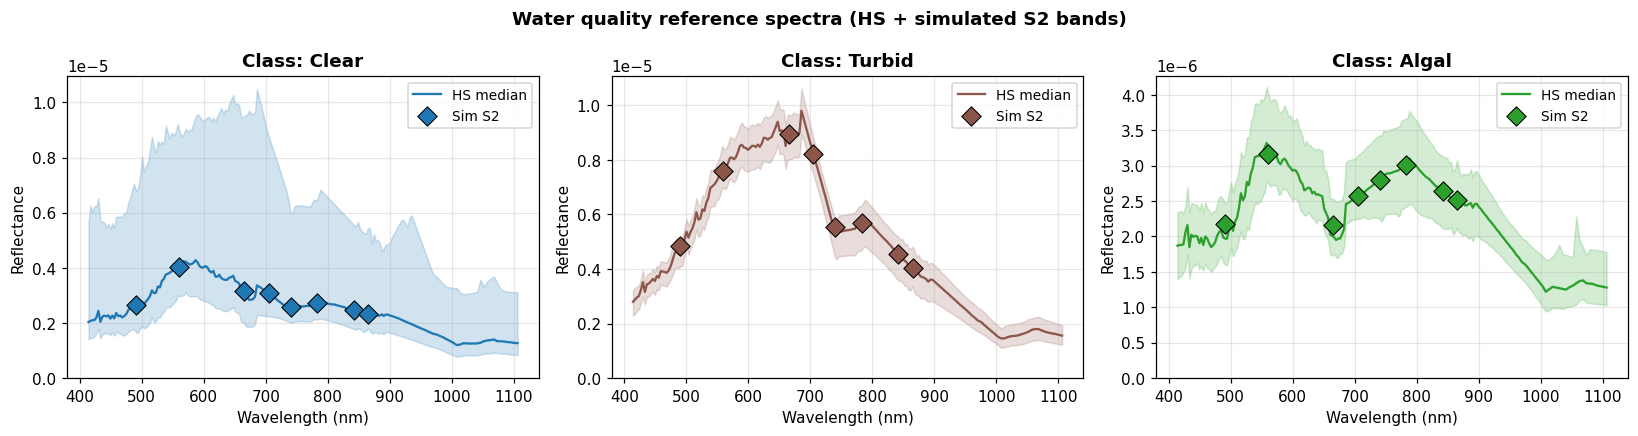

In [45]:
# ── simulate reference spectra through S2 SRFs ───────────────────────────────
def spectrum_to_s2(spectrum, wl, srfs, threshold=0.01):
    """Convert a single HS spectrum to S2-equivalent values via SRF integration."""
    s2_vals = {}
    for band_name, srf in srfs.items():
        active = srf > threshold
        s2_vals[band_name] = (np.nansum(spectrum[active] * srf[active])
                               / np.sum(srf[active]))
    return s2_vals


ref_spectra_s2 = {}
for cid, spec_hs in ref_spectra_hs.items():
    ref_spectra_s2[cid] = spectrum_to_s2(spec_hs, wl, srfs)

# ── plot reference spectra (HS + simulated S2 overlay) ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Water quality reference spectra (HS + simulated S2 bands)',
             fontweight='bold')

for ax, (cid, cname) in zip(axes, CLASS_NAMES.items()):
    color = CLASS_COLORS[cid]
    spec_hs = ref_spectra_hs[cid]

    # HS spread for the sampled pixels
    q5, q95 = np.nanpercentile(spectra_by_class[cid], [5, 95], axis=0)
    ax.fill_between(wl[:200], q5[:200], q95[:200], alpha=0.2, color=color)
    ax.plot(wl[:200], spec_hs[:200], '-', color=color, linewidth=1.5,
            label='HS median')

    # Simulated S2 as scatter
    s2_wl  = [S2_BAND_DEFS[b][0] for b in S2_BAND_DEFS if S2_BAND_DEFS[b][0] <= 1000]
    s2_val = [ref_spectra_s2[cid][b] for b in S2_BAND_DEFS if S2_BAND_DEFS[b][0] <= 1000]
    ax.scatter(s2_wl, s2_val, s=80, color=color, zorder=5, marker='D',
               edgecolors='black', linewidth=0.7, label='Sim S2')

    ax.set_title(f'Class: {cname}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Reflectance')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(OUT_DIR / 'reference_spectra.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. Spectral Angle Mapper (SAM)

Following lab_3, the spectral angle between a pixel vector $\mathbf{v}$ and a reference $\mathbf{r}$ is:

$$\theta = \arccos\!\left(\frac{\mathbf{v}\cdot\mathbf{r}}{\|\mathbf{v}\|\,\|\mathbf{r}\|}\right)$$

A smaller angle means higher spectral similarity to that class.  
We compute one SAM image per class on **both** the HS data and the calibrated S2 data.

In [46]:
def compute_sam_map(pixel_matrix, ref_spectrum):
    """
    Compute SAM angle for every row in pixel_matrix against ref_spectrum.
    pixel_matrix : (N, B) array
    ref_spectrum : (B,) array
    Returns      : (N,) array of angles in radians
    """
    dot     = pixel_matrix @ ref_spectrum
    norm_px = np.linalg.norm(pixel_matrix, axis=1)
    norm_rf = np.linalg.norm(ref_spectrum)
    denom   = norm_px * norm_rf
    # Clip to [-1, 1] to avoid numerical arccos domain errors
    cosine  = np.clip(np.divide(dot, denom, where=denom > 1e-9,
                                 out=np.zeros_like(dot)), -1, 1)
    return np.arccos(cosine)


# ─── SAM on calibrated S2 ────────────────────────────────────────────────────
# Build pixel matrix: each row is one S2 pixel, columns = bands (B02…B8A)
s2_band_order = list(S2_BAND_DEFS.keys())   # consistent ordering

def get_s2_band_10m(band_name):
    """Return calibrated S2 band resampled to 10 m grid if needed."""
    data = s2_cal[band_name]
    if data.shape != shape_10m:
        data = nd_zoom(data, (shape_10m[0]/data.shape[0],
                              shape_10m[1]/data.shape[1]), order=1)
    return data

shape_10m    = s2_cal['B04'].shape
s2_stack     = np.stack([get_s2_band_10m(b) for b in s2_band_order], axis=-1)   # (H,W,B)
s2_flat      = s2_stack.reshape(-1, len(s2_band_order))                          # (H*W, B)

sam_s2 = {}   # {class_name: 2-D angle map}
for cid, cname in CLASS_NAMES.items():
    ref_vec   = np.array([ref_spectra_s2[cid][b] for b in s2_band_order])
    sam_flat  = compute_sam_map(s2_flat, ref_vec)
    sam_s2[cname] = sam_flat.reshape(shape_10m)
    print(f'  SAM S2 vs {cname}: mean angle = {np.nanmean(sam_s2[cname][s2_water]):.3f} rad')

print('S2 SAM maps computed.')

  SAM S2 vs Clear: mean angle = 1.538 rad
  SAM S2 vs Turbid: mean angle = 1.495 rad
  SAM S2 vs Algal: mean angle = 1.567 rad
S2 SAM maps computed.


In [47]:
# ─── SAM on HS data (using full spectral resolution) ─────────────────────────
# We subsample spatially for visualisation (water pixels only)
# Full HS pixel matrix: (n_water_pixels, 456 bands)

water_rows, water_cols = np.where(water_mask_hs)
MAX_HS_SAM_PX = 50_000

if len(water_rows) > MAX_HS_SAM_PX:
    idx = np.random.choice(len(water_rows), MAX_HS_SAM_PX, replace=False)
    water_rows_s, water_cols_s = water_rows[idx], water_cols[idx]
else:
    water_rows_s, water_cols_s = water_rows, water_cols

# Read spectra for sampled pixels band-by-band
hs_pixel_mat = np.full((len(water_rows_s), n_bands), np.nan, dtype=np.float32)
for b_idx in range(n_bands):
    bd = img_008.read_bands([b_idx]).squeeze().astype(np.float32)
    bd = np.where((bd >= IGNORE_VALUE) | (bd < 0), np.nan, bd) / SCALE_FACTOR
    hs_pixel_mat[:, b_idx] = bd[water_rows_s, water_cols_s]

# Replace NaNs with 0 for the dot-product (they contribute nothing)
hs_pixel_mat_clean = np.nan_to_num(hs_pixel_mat, nan=0.0)

sam_hs = {}   # {class_name: 1-D angles for sampled water pixels}
for cid, cname in CLASS_NAMES.items():
    ref_vec      = ref_spectra_hs[cid]
    ref_vec_clean = np.nan_to_num(ref_vec, nan=0.0)
    sam_hs[cname] = compute_sam_map(hs_pixel_mat_clean, ref_vec_clean)
    print(f'  SAM HS vs {cname}: mean angle = {np.nanmean(sam_hs[cname]):.3f} rad')

print('HS SAM computed.')

  SAM HS vs Clear: mean angle = 0.602 rad
  SAM HS vs Turbid: mean angle = 0.429 rad
  SAM HS vs Algal: mean angle = 0.662 rad
HS SAM computed.


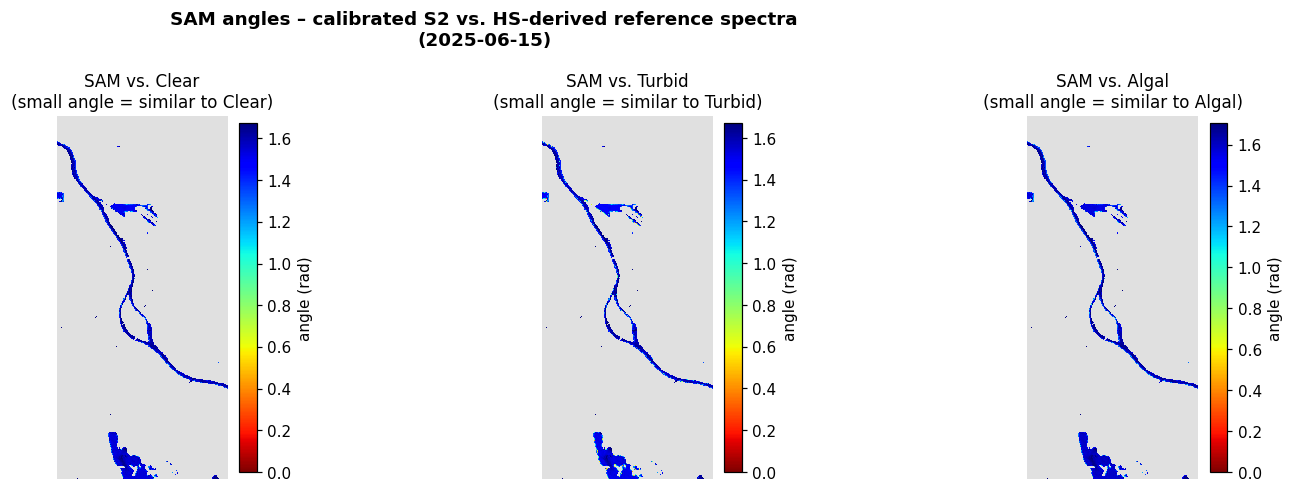

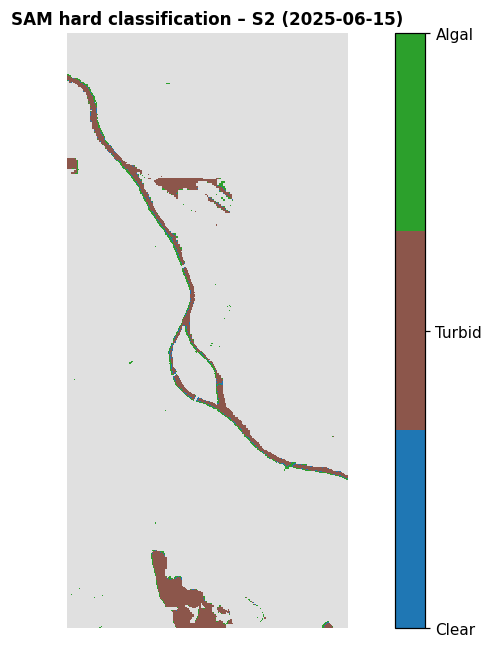

In [48]:
# ─── Visualise SAM maps (S2) ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f'SAM angles – calibrated S2 vs. HS-derived reference spectra\n({best_date})',
             fontweight='bold')

for ax, (cname, sam_map) in zip(axes, sam_s2.items()):
    disp = np.where(s2_water, sam_map, np.nan)
    vmax = np.nanpercentile(disp, 95)
    bg = np.ones((*shape_10m, 3)) * 0.88
    ax.imshow(bg)
    im = ax.imshow(disp, cmap='jet_r', vmin=0, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='angle (rad)')
    ax.set_title(f'SAM vs. {cname}\n(small angle = similar to {cname})')
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUT_DIR / 'sam_s2_maps.png', bbox_inches='tight', dpi=130)
plt.show()

# ─── Hard SAM classification (nearest reference) ─────────────────────────────
sam_stack = np.stack([sam_s2[CLASS_NAMES[cid]] for cid in CLASS_NAMES], axis=-1)  # (H,W,3)
sam_class = np.argmin(sam_stack, axis=-1).astype(np.float32)
sam_class[~s2_water] = np.nan

fig, ax = plt.subplots(figsize=(9, 6))
bg = np.ones((*shape_10m, 3)) * 0.88
ax.imshow(bg)
im = ax.imshow(sam_class,
               cmap=mcolors.ListedColormap([CLASS_COLORS[c] for c in CLASS_NAMES]),
               vmin=0, vmax=2, interpolation='nearest')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels([CLASS_NAMES[k] for k in range(3)])
ax.set_title(f'SAM hard classification – S2 ({best_date})', fontweight='bold')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUT_DIR / 'sam_hard_class_s2.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. Random Forest Water Quality Classifier

Following the structure from **lab_3** (deforestation.ipynb).  
Training data comes from the HS-derived class labels; features are computed from the calibrated S2 bands.

**Features per pixel:**
- 8 calibrated S2 bands (B02–B8A)
- 3 SAM angles (one per WQ class reference spectrum)
- NDCI, NDTI, CDOM proxy (same indices as water_quality_analysis.ipynb)

In [49]:
# ── Reproject HS class labels to S2 grid ─────────────────────────────────────
wq_class_float = wq_class.astype(np.float32)
wq_class_float[wq_class == -1] = np.nan

wq_s2grid, _ = reproject_to_s2(wq_class_float, origin_008, ref_profile)
if wq_s2grid.shape != shape_10m:
    wq_s2grid = nd_zoom(wq_s2grid, (shape_10m[0]/wq_s2grid.shape[0],
                                     shape_10m[1]/wq_s2grid.shape[1]), order=0)

# Round to nearest integer class (nearest-neighbour after reprojection)
wq_s2grid_int = np.round(wq_s2grid).astype(np.int8)
wq_s2grid_int[~np.isfinite(wq_s2grid) | ~calib_mask] = -1

for cid, cname in CLASS_NAMES.items():
    n = (wq_s2grid_int == cid).sum()
    print(f'  Class {cid} ({cname}): {n:,} S2-grid pixels')

  Class 0 (Clear): 45 S2-grid pixels
  Class 1 (Turbid): 771 S2-grid pixels
  Class 2 (Algal): 0 S2-grid pixels


In [50]:
# ── build feature matrix ──────────────────────────────────────────────────────
# Only use pixels with known class labels (from HS overlap region)
labelled_mask = (wq_s2grid_int >= 0) & s2_water & hs_coverage

# Calibrated S2 bands
band_arrays = [get_s2_band_10m(b) for b in s2_band_order]

# SAM angles (already on S2 grid)
sam_arrays = [sam_s2[cname] for cname in CLASS_NAMES.values()]

# Water quality indices from calibrated S2
B04 = get_s2_band_10m('B04')
B03 = get_s2_band_10m('B03')
B05 = get_s2_band_10m('B05')
B07 = get_s2_band_10m('B07')
B02 = get_s2_band_10m('B02')

ndci_s2 = (B05 - B04) / (B05 + B04 + 1e-9)
ndti_s2 = (B04 - B03) / (B04 + B03 + 1e-9)
cdom_s2 = B02 / (B04 + 1e-9)

index_arrays = [ndci_s2, ndti_s2, cdom_s2]

feature_arrays = band_arrays + sam_arrays + index_arrays
feature_names  = (s2_band_order
                  + [f'SAM_{CLASS_NAMES[c]}' for c in CLASS_NAMES]
                  + ['NDCI', 'NDTI', 'CDOM'])

# Stack and extract labelled samples
X_all = np.stack([a[labelled_mask] for a in feature_arrays], axis=1)  # (N, F)
y_all = wq_s2grid_int[labelled_mask]

# Drop rows with NaN
ok = np.all(np.isfinite(X_all), axis=1)
X_all, y_all = X_all[ok], y_all[ok]

print(f'Labelled pixels: {len(X_all):,}  |  features: {X_all.shape[1]}')
for cid, cname in CLASS_NAMES.items():
    print(f'  {cname}: {(y_all == cid).sum():,}')

Labelled pixels: 816  |  features: 14
  Clear: 45
  Turbid: 771
  Algal: 0


In [51]:
# ── train/test split (25 % test, stratified — same as lab_3) ─────────────────
label_names = [CLASS_NAMES[c] for c in y_all]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, label_names, test_size=0.25, stratify=label_names, random_state=42
)

from collections import Counter
print('Training set:', Counter(y_train))
print('Test set:    ', Counter(y_test))

Training set: Counter({'Turbid': 578, 'Clear': 34})
Test set:     Counter({'Turbid': 193, 'Clear': 11})


In [52]:
# ── GridSearchCV for hyperparameters (same structure as lab_3) ────────────────
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [10, 20, None],
    'class_weight':  ['balanced'],
}

clf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
)
clf.fit(X_train, y_train)

print('Best params:  ', clf.best_params_)
print('CV score:      {:.3f}'.format(clf.best_score_))

Best params:   {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}
CV score:      0.517


In [53]:
# ── evaluate on test set ──────────────────────────────────────────────────────
y_pred = clf.predict(X_test)
print('Test accuracy:  {:.3f}'.format(accuracy_score(y_test, y_pred)))
print()
print(classification_report(y_test, y_pred,
                              target_names=[CLASS_NAMES[c] for c in CLASS_NAMES]))

Test accuracy:  0.946



ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

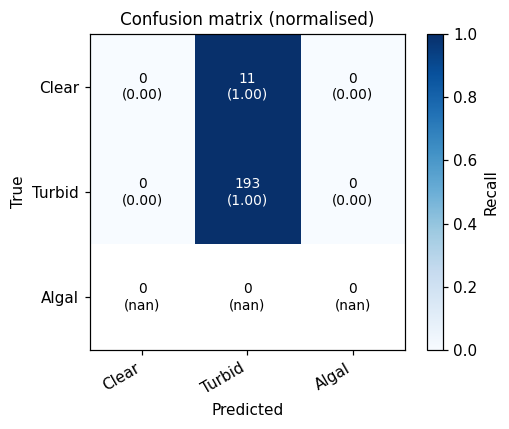

In [54]:
# ── confusion matrix ──────────────────────────────────────────────────────────
import itertools

cm      = confusion_matrix(y_test, y_pred,
                            labels=[CLASS_NAMES[c] for c in CLASS_NAMES])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
classes = [CLASS_NAMES[c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Recall')
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_yticklabels(classes)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.2f})',
            ha='center', va='center',
            color='white' if cm_norm[i, j] > 0.6 else 'black', fontsize=9)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix (normalised)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'confusion_matrix.png', bbox_inches='tight', dpi=130)
plt.show()

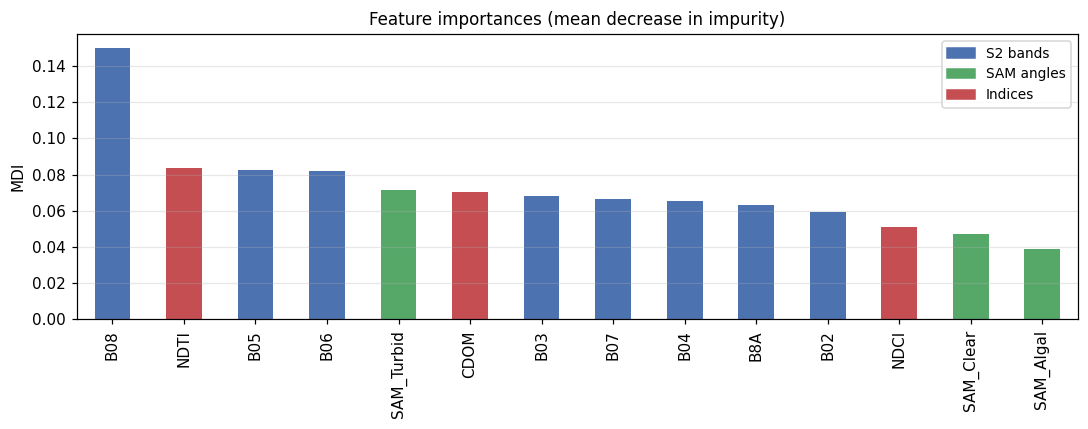

In [55]:
# ── feature importance (same as lab_3 cell 41) ────────────────────────────────
importances = clf.best_estimator_.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
fi.plot.bar(ax=ax, color=[
    '#4C72B0' if n.startswith('B') else
    '#55A868' if n.startswith('SAM') else
    '#C44E52' for n in fi.index
])
ax.set_title('Feature importances (mean decrease in impurity)')
ax.set_ylabel('MDI')
ax.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4C72B0', label='S2 bands'),
    Patch(color='#55A868', label='SAM angles'),
    Patch(color='#C44E52', label='Indices'),
], fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()

## 8. Apply Classifier to Full Sentinel-2 Scene

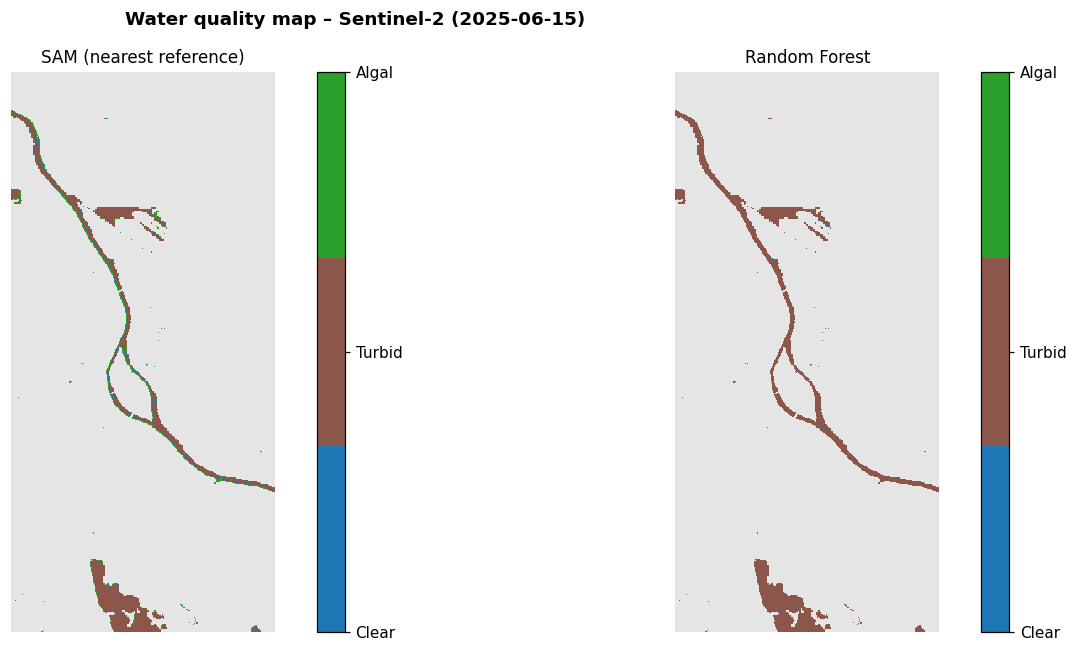

Total S2 water pixels: 8,826
  Clear: 54  (0.6 %)
  Turbid: 8,772  (99.4 %)
  Algal: 0  (0.0 %)


In [56]:
# Build feature matrix for every water pixel in the S2 scene
X_scene = np.stack([a[s2_water] for a in feature_arrays], axis=1)
ok_scene = np.all(np.isfinite(X_scene), axis=1)

# Predict
pred_flat = np.full(s2_water.sum(), 'Unknown', dtype=object)
pred_flat[ok_scene] = clf.predict(X_scene[ok_scene])

# Reassemble to 2-D
pred_map = np.full(shape_10m, np.nan, dtype=np.float32)
name_to_id = {v: k for k, v in CLASS_NAMES.items()}
pred_int = np.array([name_to_id.get(p, -1) for p in pred_flat], dtype=np.float32)
pred_map[s2_water] = pred_int
pred_map[pred_map < 0] = np.nan

# ── plot: SAM hard classification vs. RF classification ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Water quality map – Sentinel-2 ({best_date})', fontweight='bold')

class_cmap = mcolors.ListedColormap([CLASS_COLORS[c] for c in CLASS_NAMES])

for ax, (data, title) in zip(axes, [(sam_class, 'SAM (nearest reference)'),
                                      (pred_map, 'Random Forest')]):
    bg = np.ones((*shape_10m, 3)) * 0.9
    ax.imshow(bg)
    im = ax.imshow(data, cmap=class_cmap, vmin=0, vmax=2, interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels([CLASS_NAMES[k] for k in range(3)])
    ax.set_title(title)
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUT_DIR / 'wq_final_maps.png', bbox_inches='tight', dpi=130)
plt.show()

# Summary stats
total_water = s2_water.sum()
print(f'Total S2 water pixels: {total_water:,}')
for cid, cname in CLASS_NAMES.items():
    n = (pred_map == cid).sum()
    print(f'  {cname}: {n:,}  ({100*n/total_water:.1f} %)')

In [57]:
print('All outputs saved to:', OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob('*.png')):
    print(' ', f.name)

All outputs saved to: /Users/michalkawa/space-tech/remote-sensing/eolabs/lab_5/outputs
  calibration_comparison.png
  comparison_boxplots.png
  composites_block_008.png
  composites_block_013.png
  composites_block_015.png
  confusion_matrix.png
  elc_calibration_scatter.png
  feature_importance.png
  hs_simulated_s2_composites.png
  ndci_scatter_hs_vs_s2.png
  ndci_spatial_comparison.png
  reference_spectra.png
  s2_water_mask.png
  sam_hard_class_s2.png
  sam_s2_maps.png
  srf_plot.png
  water_mask_block_008.png
  water_mask_block_013.png
  water_mask_block_015.png
  wq_class_map_hs.png
  wq_final_maps.png
  wq_indices_hs_block_008.png
  wq_indices_hs_block_013.png
  wq_indices_hs_block_015.png
  wq_indices_s2.png
  wq_summary_dashboard.png
